In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from oetils import init_plotting

In [2]:
_ = init_plotting(latex=True, sans=True)

---

# Exercise 4.1

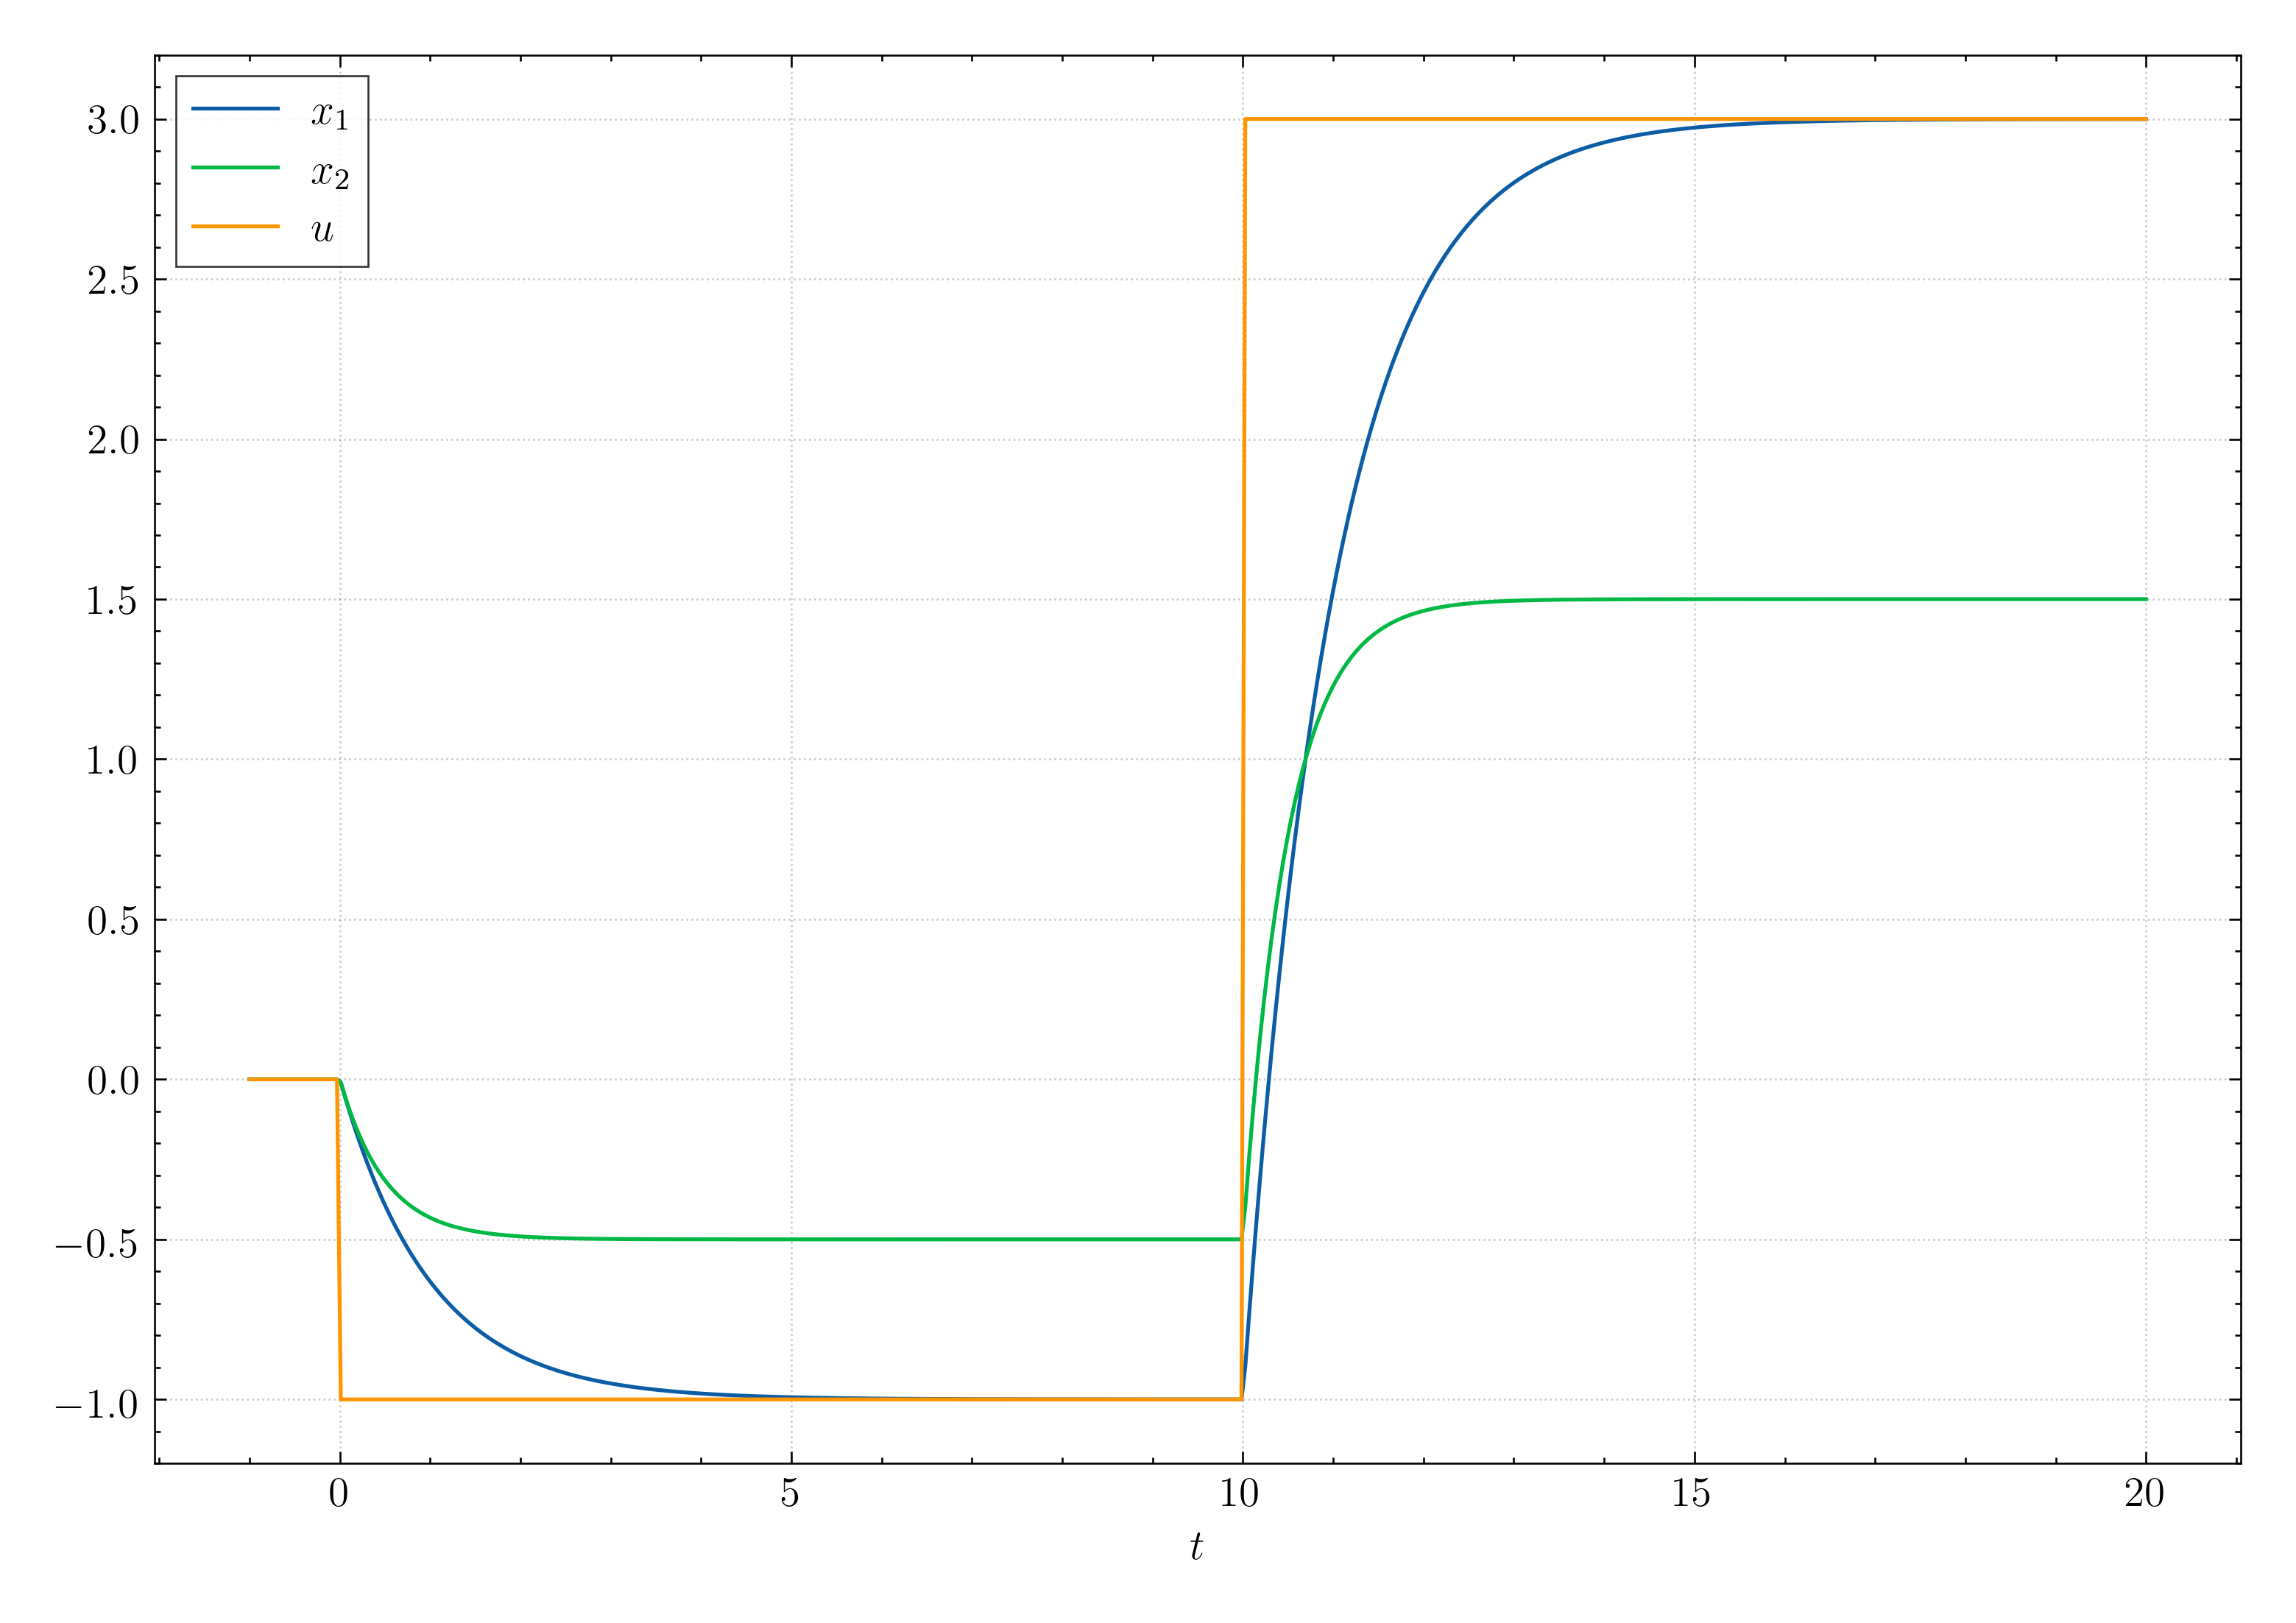

In [3]:
t, tau = sp.S('t, tau')
A = sp.Matrix([[-1, 0], [0, -2]])
B = sp.Matrix([[1], [1]])

u = -1 * sp.Heaviside(tau) + 4 * sp.Heaviside(tau - 10)
x = sp.integrate(sp.exp(A*(t - tau)) @ B * u, (tau, 0, t))

ts = np.linspace(-1, 20, 500)
xs = sp.lambdify(t, x)(ts)[:, 0]
us = sp.lambdify(tau, u)(ts)
fig, ax = plt.subplots()
ax.set_xlabel('$t$')
ax.plot(ts, xs[0], label='$x_1$')
ax.plot(ts, xs[1], label='$x_2$')
ax.plot(ts, us, label='$u$')
ax.legend()
plt.show()

# Exercise 4.3

In [4]:
t, tau, t_, x1, x2, x01, x02 = sp.symbols("t, tau, t', x^1, x^2, x_0^1, x_0^2")
A = sp.Matrix([[0, 0], [1, 0]])
B = sp.Matrix([[1], [1]])
x = sp.Matrix([[x1], [x2]])
x0 = sp.Matrix([[x01], [x02]])

In [5]:
eat = sp.exp(A*t)
eat

Matrix([
[1, 0],
[t, 1]])

In [6]:
ir = eat @ B
ir

Matrix([
[    1],
[t + 1]])

In [7]:
P = sp.integrate(ir @ ir.T, (t, 0, tau))
P

Matrix([
[           tau,          tau**2/2 + tau],
[tau**2/2 + tau, tau**3/3 + tau**2 + tau]])

In [8]:
u = (ir.subs(t, tau - t).T @ P.inv() @ (x - sp.exp(A*tau) @ x0))[0]
u

(x^1 - x_0^1)*((-6*tau - 12)*(-t + tau + 1)/tau**3 + (4*tau**2 + 12*tau + 12)/tau**3) + ((-6*tau - 12)/tau**3 + 12*(-t + tau + 1)/tau**3)*(-tau*x_0^1 + x^2 - x_0^2)

In [9]:
# Final state at time t = tau
(eat @ x0 + sp.integrate(ir.subs(t, tau - t) * u, (t, 0, tau))).subs(t, tau).simplify()

Matrix([
[x^1],
[x^2]])

In [10]:
# Concrete control trajectory for example
subs = [(x01, 1), (x02, 0), (x1, 1), (x2, -sp.S(1)/2), (tau, 10)]
u = u.subs(subs)
u

63*t/500 - 63/100

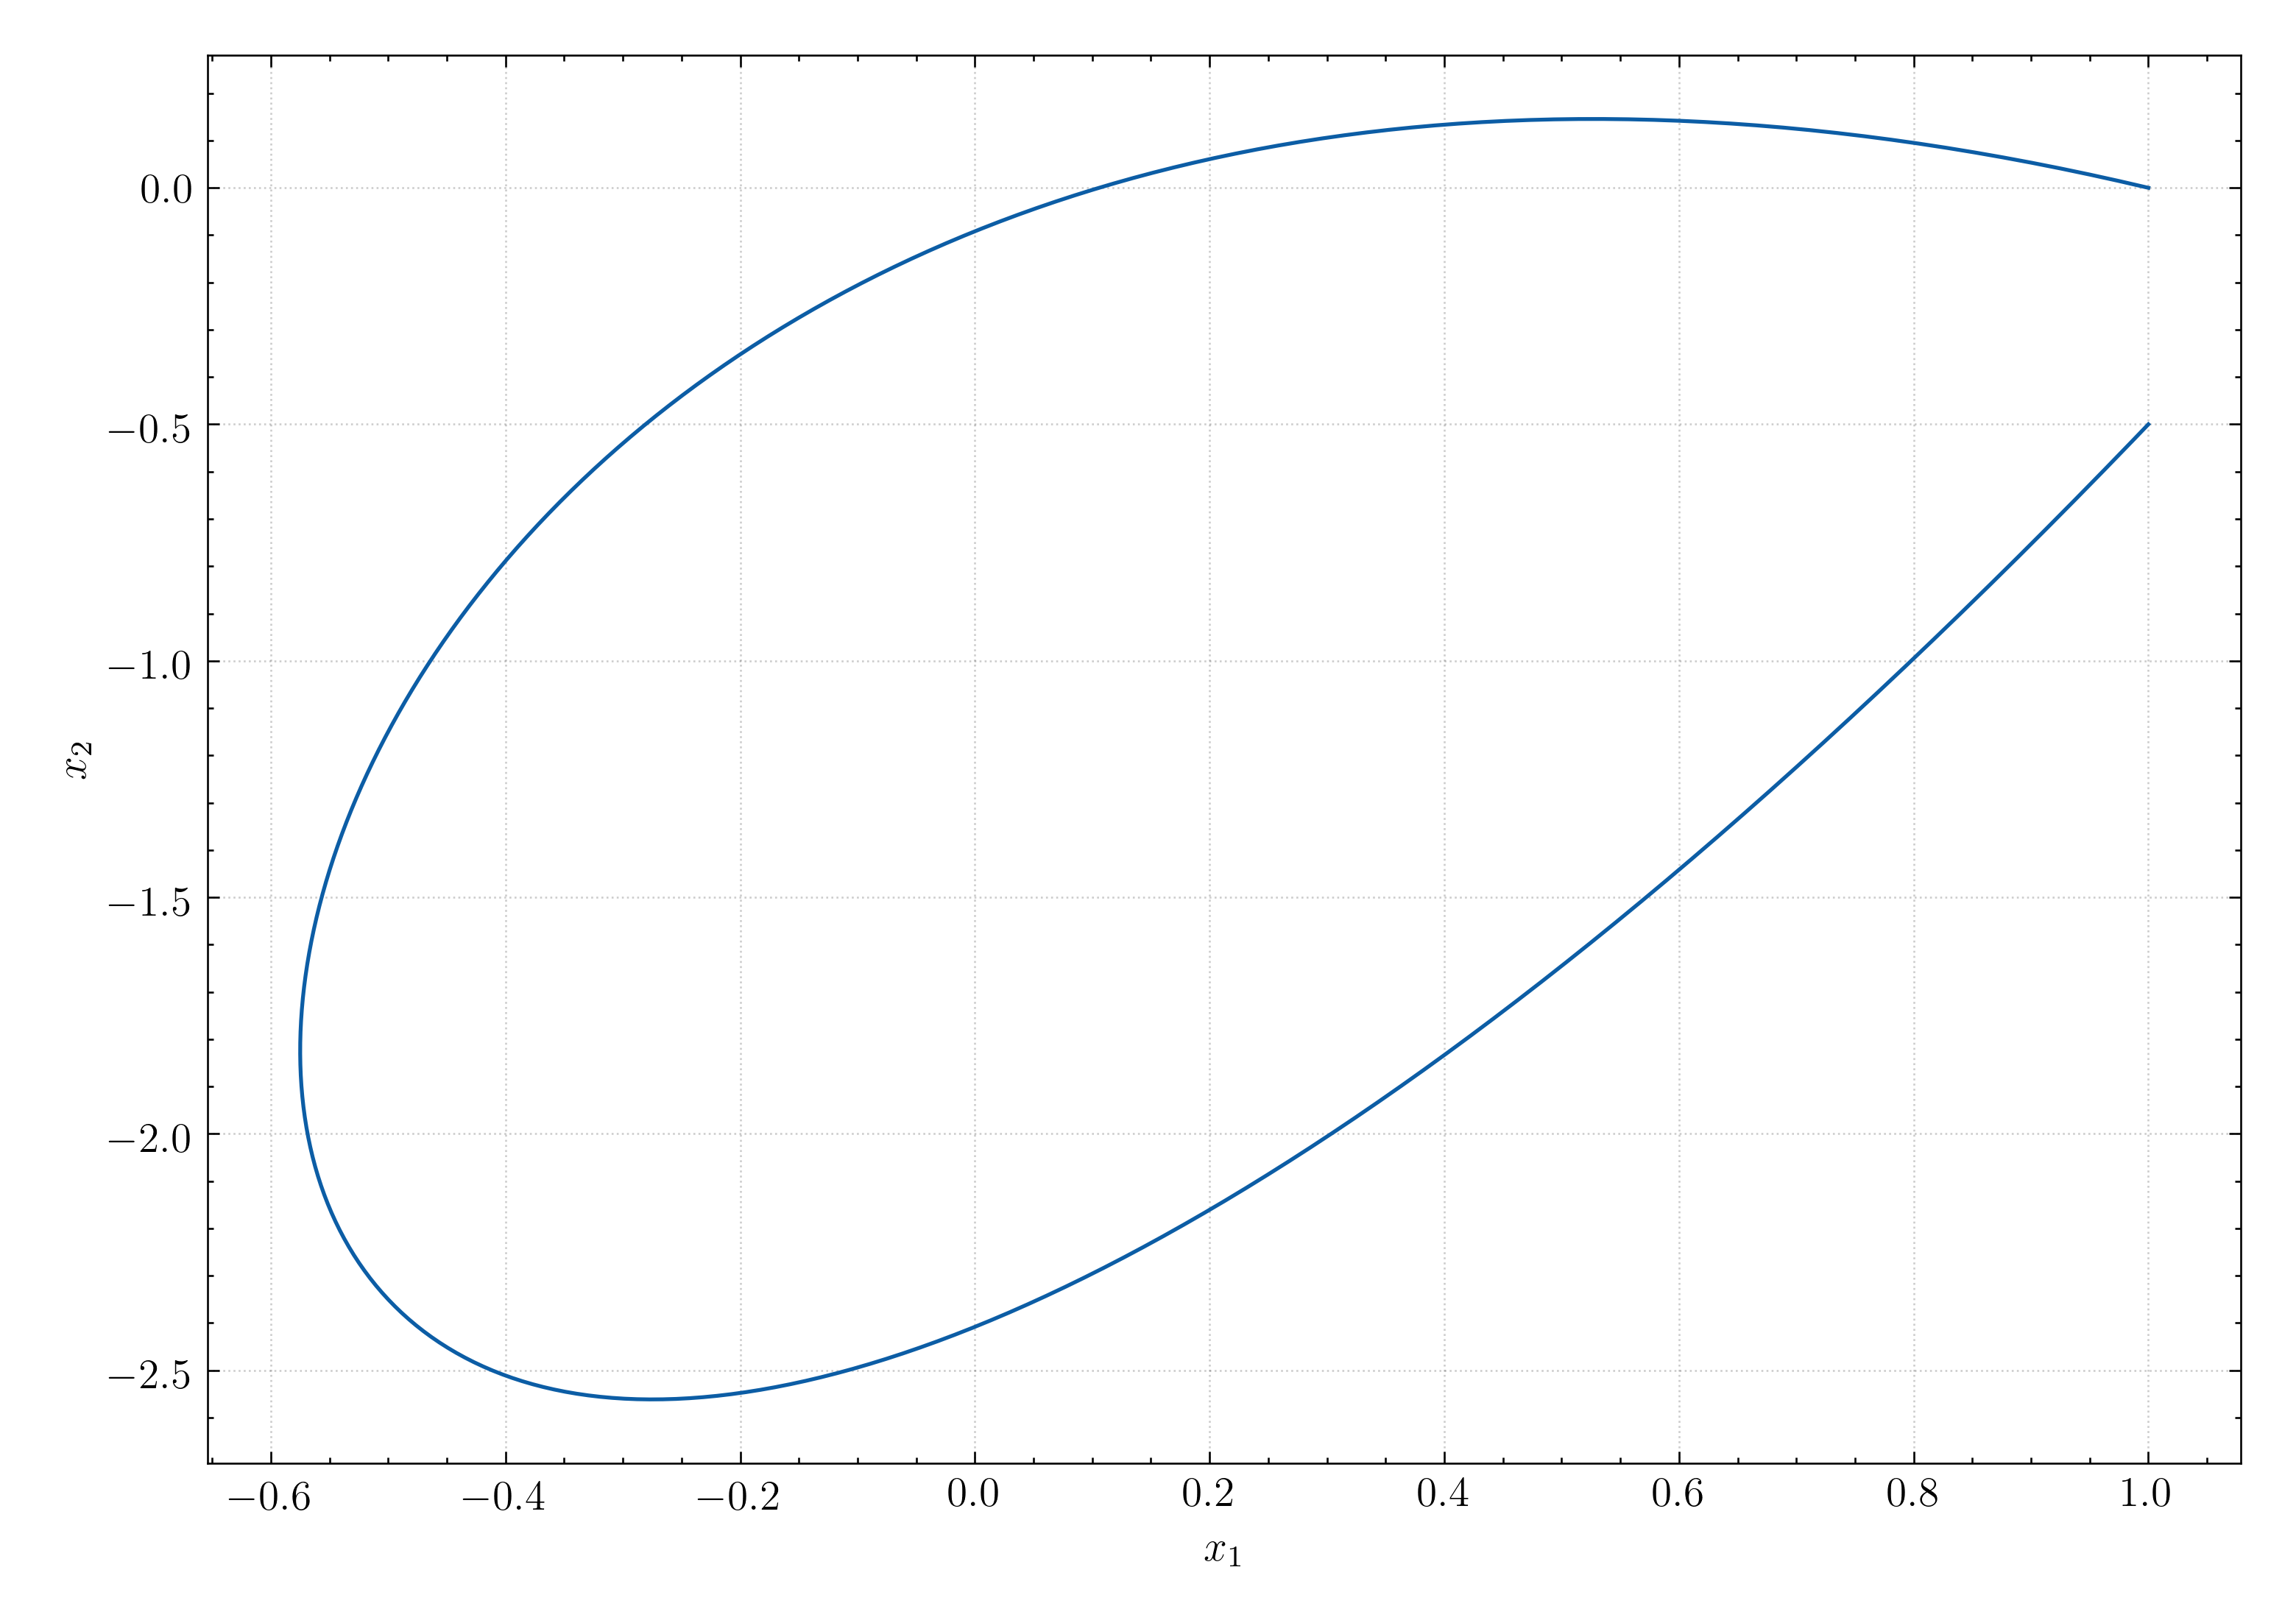

In [11]:
# Compute and plot state trajectory
x = (eat @ x0 + sp.integrate(ir.subs(t, t - t_) * u.subs(t, t_), (t_, 0, t))).subs(subs).simplify()

ts = np.linspace(0, 10, 500)
xt = sp.lambdify(t, x)
xs = np.array([xt(t) for t in ts])[..., 0]
fig, ax = plt.subplots()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.plot(xs[:, 0], xs[:, 1])
plt.show()